In [3]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

#for interactive plots from pandas dataframe

import plotly.express as px
%matplotlib inline

today_date = dt.datetime.today().date()
today_date
start_date = today_date -pd.Timedelta(days=59)
start_date

datetime.date(2026, 4, 22)

In [5]:
df= yf.download("NVDA", start=start_date, end= today_date, interval='5m', auto_adjust= False)
df
desired_columns = ['Open', 'High','Low','Close','Adj Close','Volume']

#filter and reorder columns
df = df[[col for col in desired_columns if col in df.columns]]
df.columns = df.columns.droplevel(1)
df.columns
print(type(df))
df.head()
df.tail()


[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>


Price,Open,High,Low,Close,Adj Close,Volume
Datetime,,,,,,
2026-06-18 19:35:00+00:00,209.789993,210.220001,209.779999,210.220001,210.220001,1194806
2026-06-18 19:40:00+00:00,210.220001,210.270004,210.070007,210.154999,210.154999,999909
2026-06-18 19:45:00+00:00,210.154999,210.500000,209.929993,210.150101,210.150101,2926831
2026-06-18 19:50:00+00:00,210.160004,211.389999,210.089996,211.070007,211.070007,4119416
2026-06-18 19:55:00+00:00,211.087997,211.220001,210.223999,210.229996,210.229996,5674033


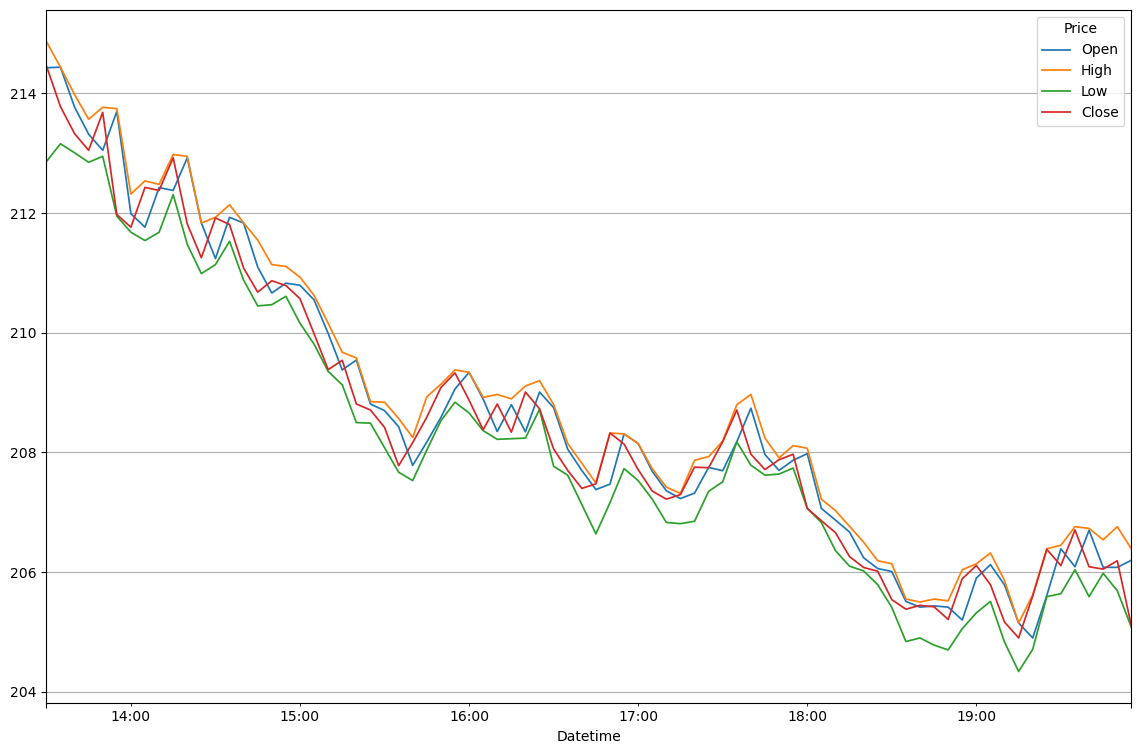

In [7]:

df1a = df.copy()
%matplotlib inline
df1a.loc['2026-06-05', ['Open','High','Low','Close']].plot(grid=True, linewidth=1.25, figsize=(14,9));
plt.show()

In [9]:

df1a.drop(columns=['High', 'Low', 'Volume'], inplace=True)
df1a['cc_returns'] = df1a['Close'].pct_change()
sma=12
df1a['sma'] = df1a['Close'].rolling(window=sma).mean()

In [11]:
print(type(df1a['Close']))
print(type(df1a['sma']))
print(df1a.columns)
df1a['position'] = np.where((df1a['Close']> df1a['sma']), 1, 0)
df1a['position'] = df1a['position'].shift(1)

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
Index(['Open', 'Close', 'Adj Close', 'cc_returns', 'sma'], dtype='object', name='Price')


In [13]:
df1a['position'].value_counts()

position
1.0    1624
0.0    1573
Name: count, dtype: int64

In [15]:
df1a['strategy_returns'] = df1a['cc_returns']*df1a['position']
df1a.tail()

Price,Open,Close,Adj Close,cc_returns,sma,position,strategy_returns
Datetime,,,,,,,
2026-06-18 19:35:00+00:00,209.789993,210.220001,210.220001,0.002097,209.966676,0.0,0.000000
2026-06-18 19:40:00+00:00,210.220001,210.154999,210.154999,-0.000309,209.966259,1.0,-0.000309
2026-06-18 19:45:00+00:00,210.154999,210.150101,210.150101,-0.000023,209.982109,1.0,-0.000023
2026-06-18 19:50:00+00:00,210.160004,211.070007,211.070007,0.004377,210.089601,1.0,0.004377
2026-06-18 19:55:00+00:00,211.087997,210.229996,210.229996,-0.003980,210.133767,1.0,-0.003980


In [17]:
df1a['strategy_returns'] = 1 + df1a['strategy_returns']

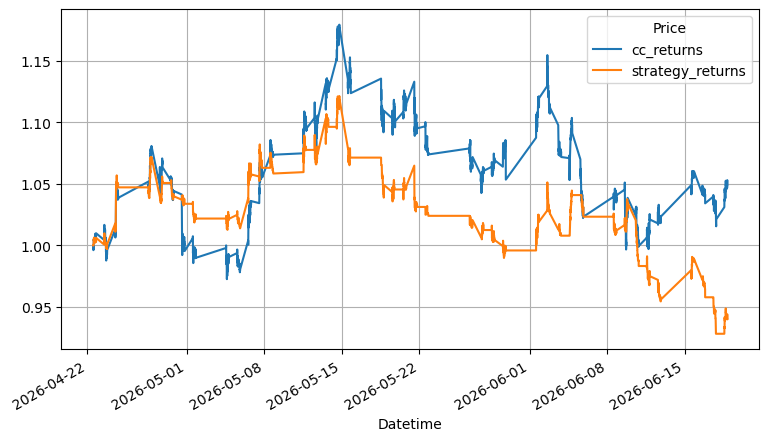

In [19]:
df1a['cc_returns'] = 1+df1a['cc_returns']
df1a[['cc_returns','strategy_returns']].cumprod().plot(grid=True, figsize=(9,5));
plt.show()

In [21]:
print('Buy and hold returns:', np.round(df1a['cc_returns'].cumprod()[-1]-1,2))
print('strategy_returns:', np.round(df1a['strategy_returns'].cumprod()[-1]-1,2))


Buy and hold returns: 0.05
strategy_returns: -0.06


In [21]:
#Using EMA Strategy Analysis

In [35]:
df1b = df.copy()

df1b['cc_returns'] = df1b['Close'].pct_change()

ema = 12
df1b['ema'] = df1b['Close'].ewm(span=ema, adjust=False).mean()
print(df1b.head())
print(df1b.tail())
df1b['position'] = np.where((df1b['Close']> df1b['ema']),1,0)
df1b['position'] = df1b['position'].shift(2)

df1b['position'].value_counts()
print(df1b.head())
print(df1b.tail())

df1b['strategy_returns'] = df1b['cc_returns']*df1b['position']
df1b['strategy_returns'] = 1 + df1b['strategy_returns']
df1b['cc_returns'] = 1 + df1b['cc_returns']
df1b.tail()


Price                            Open        High         Low       Close  \
Datetime                                                                    
2026-04-22 13:30:00+00:00  201.000000  201.100006  200.110001  200.440002   
2026-04-22 13:35:00+00:00  200.419998  200.679993  199.994995  199.994995   
2026-04-22 13:40:00+00:00  200.000000  200.559998  199.979996  200.419998   
2026-04-22 13:45:00+00:00  200.419998  200.610001  199.699997  199.880096   
2026-04-22 13:50:00+00:00  199.899994  200.110001  199.559998  200.024994   

Price                       Adj Close   Volume  cc_returns         ema  
Datetime                                                                
2026-04-22 13:30:00+00:00  200.440002  6135383         NaN  200.440002  
2026-04-22 13:35:00+00:00  199.994995  2055092   -0.002220  200.371540  
2026-04-22 13:40:00+00:00  200.419998  1845092    0.002125  200.378995  
2026-04-22 13:45:00+00:00  199.880096  2117889   -0.002694  200.302241  
2026-04-22 13:50:00+00

Price,Open,High,Low,Close,Adj Close,Volume,cc_returns,ema,position,strategy_returns
Datetime,,,,,,,,,,
2026-06-18 19:35:00+00:00,209.789993,210.220001,209.779999,210.220001,210.220001,1194806,1.002097,209.991706,0.0,1.000000
2026-06-18 19:40:00+00:00,210.220001,210.270004,210.070007,210.154999,210.154999,999909,0.999691,210.016828,0.0,1.000000
2026-06-18 19:45:00+00:00,210.154999,210.500000,209.929993,210.150101,210.150101,2926831,0.999977,210.037331,1.0,0.999977
2026-06-18 19:50:00+00:00,210.160004,211.389999,210.089996,211.070007,211.070007,4119416,1.004377,210.196205,1.0,1.004377
2026-06-18 19:55:00+00:00,211.087997,211.220001,210.223999,210.229996,210.229996,5674033,0.996020,210.201403,1.0,0.996020


In [39]:

df1b[['cc_returns','strategy_returns']].cumprod().plot(grid=True, figsize=(9,5));
print('buy and hold returns:',np.round(df1b['cc_returns'].cumprod()[-1],2))
print('strategy returns:',np.round(df1b['strategy_returns'].cumprod()[-1],2))                                   

buy and hold returns: 1.05
strategy returns: 0.92
